# Pranjal babu koirala
# student id : 2407642
# Hate Speech & Offensive Language Detection
### Text Classification with RNN / LSTM (6CS012 – Final Portfolio Part 3)
---

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0 · Installations & Environment Setup

In [2]:
# ── Clean slate (Colab sometimes ships incompatible keras versions) ──
!pip uninstall -y keras keras-hub tensorflow tensorflow-intel tensorflow-cpu jax jaxlib flax optax orbax-checkpoint -q
!pip install tensorflow==2.19.1 -q
!pip install scikit-learn pandas matplotlib seaborn wordcloud gensim nltk gradio -q
print('All packages installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 30.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires flax>=0.2.0, which is not installed.
dopamine-rl 4.1.2 requires jax>=0.1.72, which is not installed.
dopamine-rl 4.1.2 requires jaxlib>=0.1.51, which is not installed.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.1 which is incompatible.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.19.1 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.19.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 46.2 MB/s eta 0:00:00
All p

## 1 · Imports

In [3]:
import os, zipfile, re, string, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')

# ── NLP ──
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)
from nltk.corpus import stopwords
from nltk.stem  import WordNetLemmatizer
from wordcloud  import WordCloud

# ── Sklearn ──
from sklearn.model_selection  import train_test_split
from sklearn.metrics          import (classification_report,
                                       confusion_matrix, ConfusionMatrixDisplay,
                                       accuracy_score, precision_score, recall_score, f1_score)

# ── Keras / TensorFlow ──
import tensorflow as tf
from tensorflow.keras.preprocessing.text     import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models   import Sequential
from tensorflow.keras.layers   import (Embedding, SimpleRNN, LSTM,
                                        Dense, Dropout, Bidirectional)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils     import to_categorical

# ── Word2Vec / pretrained embeddings ──
from gensim.models import Word2Vec
import gensim.downloader as api

print(f'TensorFlow {tf.__version__}  |  NumPy {np.__version__}')
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

TensorFlow 2.19.1  |  NumPy 2.0.2


## 2 · Load Dataset


In [74]:
import os
import zipfile

# ======================================================
# PATH YOU PROVIDED (FOLDER CONTAINING DATASET)
# ======================================================

DATASET_PATH = "/content/drive/MyDrive/ Ai and machine learning/Collection of Dataset for Text Classification/4. Hate Speech Detection Dataset"

EXTRACT_DIR = "/content/data"
os.makedirs(EXTRACT_DIR, exist_ok=True)

# ======================================================
# STEP 1 — CHECK IF PATH IS ZIP OR FOLDER
# ======================================================

if DATASET_PATH.endswith(".zip"):
    print("ZIP file detected → Extracting...")

    with zipfile.ZipFile(DATASET_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
        print("Extracted files:", z.namelist())

    SEARCH_PATH = EXTRACT_DIR

else:
    print("Folder detected → Using directly")
    SEARCH_PATH = DATASET_PATH


# ======================================================
# STEP 2 — AUTO FIND CSV FILE
# ======================================================

csv_files = []

for root, dirs, files in os.walk(SEARCH_PATH):
    for f in files:
        if f.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, f))

if len(csv_files) == 0:
    raise FileNotFoundError(" No CSV file found inside dataset.")

print("\nCSV files found:")
for i, f in enumerate(csv_files):
    print(f"{i+1}. {f}")

CSV_PATH = csv_files[0]
print(f"\n Using CSV: {CSV_PATH}")

Folder detected → Using directly

CSV files found:
1. /content/drive/MyDrive/ Ai and machine learning/Collection of Dataset for Text Classification/4. Hate Speech Detection Dataset/hatevsoffensive_language.csv

 Using CSV: /content/drive/MyDrive/ Ai and machine learning/Collection of Dataset for Text Classification/4. Hate Speech Detection Dataset/hatevsoffensive_language.csv


In [72]:
df = pd.read_csv(CSV_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (24783, 2)


,label,text
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,offensive language,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,offensive language,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


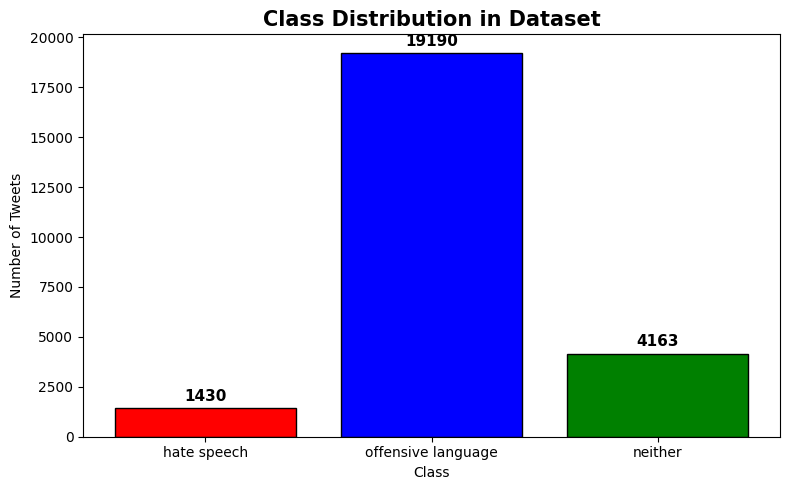

In [73]:
import matplotlib.pyplot as plt

TEXT_COL  = 'text'
LABEL_COL = 'label'

# Keep only required columns
df = df[[TEXT_COL, LABEL_COL]].dropna().reset_index(drop=True)

# Clean labels
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip().str.lower()
df[LABEL_COL] = df[LABEL_COL].replace({'hate speec': 'hate speech'})

# Label mapping
label_map = {
    'hate speech': 0,
    'offensive language': 1,
    'neither': 2
}

CLASS_NAMES = {
    0: 'hate speech',
    1: 'offensive language',
    2: 'neither'
}

df[LABEL_COL] = df[LABEL_COL].map(label_map)
df = df.dropna(subset=[LABEL_COL]).reset_index(drop=True)
df[LABEL_COL] = df[LABEL_COL].astype(int)

# ======================
# style
# ======================

fig, ax = plt.subplots(figsize=(8,5))

counts = df[LABEL_COL].value_counts().sort_index()

# Different color for each bar
colors = ['red', 'blue', 'green']   # change freely

bars = ax.bar(
    [CLASS_NAMES[i] for i in counts.index],
    counts.values,
    color=colors,
    edgecolor='black'
)

ax.bar_label(bars, padding=3, fontsize=11, fontweight='bold')

ax.set_title('Class Distribution in Dataset', fontsize=15, fontweight='bold')
ax.set_ylabel('Number of Tweets')
ax.set_xlabel('Class')

plt.tight_layout()
plt.show()

## 3 · Text Preprocessing & Tokenization
### 3.1 Cleaning Pipeline

In [56]:
STOP_WORDS  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

# Contraction dictionary (partial – expand as needed)
CONTRACTIONS = {
    "don't":"do not",  "doesn't":"does not", "didn't":"did not",
    "won't": "will not","wouldn't":"would not","can't":"cannot",
    "couldn't":"could not","shouldn't":"should not","isn't":"is not",
    "aren't":"are not",  "wasn't":"was not",   "weren't":"were not",
    "haven't":"have not","hasn't":"has not",   "hadn't":"had not",
    "i'm":"i am",        "i've":"i have",       "i'll":"i will",
    "i'd":"i would",     "you're":"you are",    "you've":"you have",
    "you'll":"you will", "you'd":"you would",   "he's":"he is",
    "she's":"she is",    "it's":"it is",        "they're":"they are",
    "they've":"they have","they'll":"they will","we're":"we are",
    "we've":"we have",   "we'll":"we will",     "that's":"that is",
    "there's":"there is","let's":"let us",      "who's":"who is",
    "what's":"what is",  "n't":" not"
}

def expand_contractions(text: str) -> str:
    for k, v in CONTRACTIONS.items():
        text = re.sub(re.escape(k), v, text, flags=re.IGNORECASE)
    return text

def clean_text(text: str) -> str:
    text = str(text).lower()                           # 1. lowercase
    text = expand_contractions(text)                   # 2. contractions
    text = re.sub(r'http\S+|www\.\S+', '', text)      # 3. URLs
    text = re.sub(r'@\w+', '', text)                   # 4. mentions
    text = re.sub(r'#\w+', '', text)                   # 5. hashtags
    text = re.sub(r'\d+', '', text)                    # 6. numbers
    text = re.sub(r'[^\w\s]', '', text)                # 7. punctuation
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS]# 8. stopwords
    tokens = [lemmatizer.lemmatize(t) for t in tokens] # 9. lemmatize
    return ' '.join(tokens)

df['clean_text'] = df[TEXT_COL].apply(clean_text)

print('Sample cleaned tweets:')
for i in range(3):
    print(f'  Original : {df[TEXT_COL][i]}')
    print(f'  Cleaned  : {df["clean_text"][i]}')
    print()

Sample cleaned tweets:
  Original : !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...
  Cleaned  : rt woman complain cleaning house amp man always take trash

  Original : !!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!
  Cleaned  : rt boy dat coldtyga dwn bad cuffin dat hoe st place

  Original : !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You be confused as shit
  Cleaned  : rt dawg rt ever fuck bitch start cry confused shit



### 3.2 Visualise Cleaned Data – Word Clouds per Class

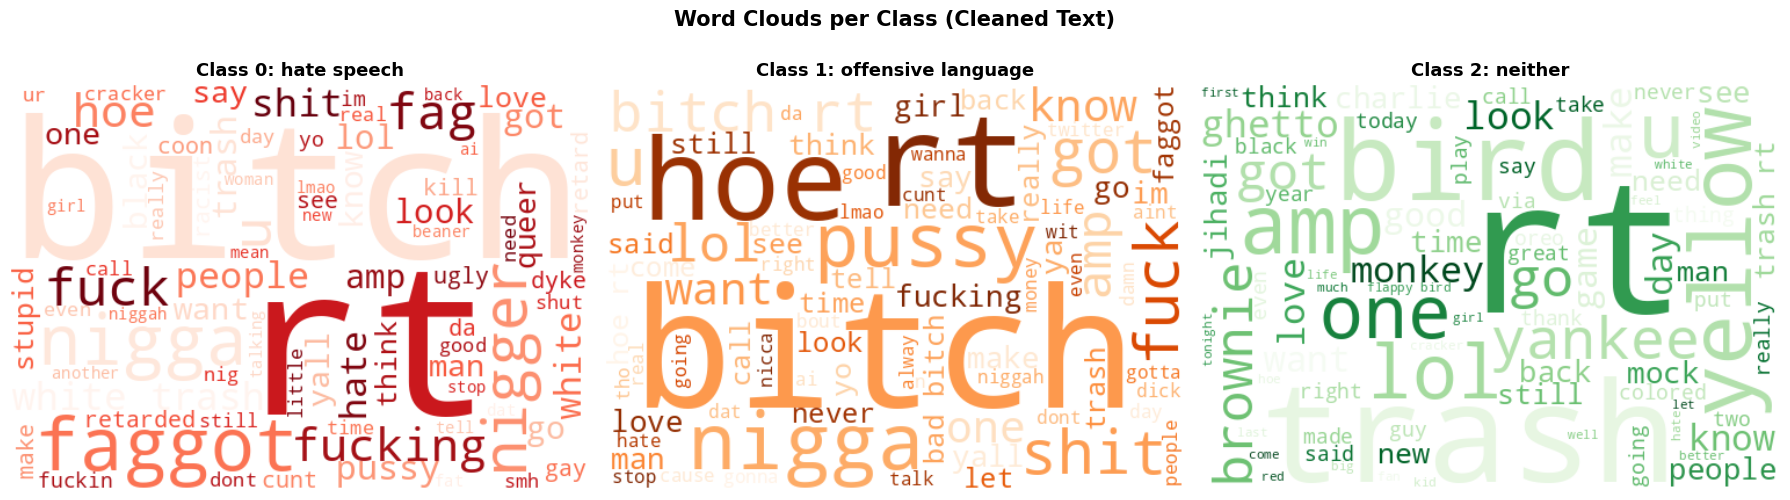

In [57]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(18, 5))
colors = ['Reds', 'Oranges', 'Greens']

for idx, (label, name) in enumerate(CLASS_NAMES.items()):
    corpus = ' '.join(df[df[LABEL_COL] == label]['clean_text'])
    if not corpus.strip():
        axes[idx].axis('off'); continue
    wc = WordCloud(width=500, height=350, background_color='white',
                   colormap=colors[idx], max_words=80).generate(corpus)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(f'Class {label}: {name}', fontsize=13, fontweight='bold')

plt.suptitle('Word Clouds per Class (Cleaned Text)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Top-20 Most Frequent Words per Class

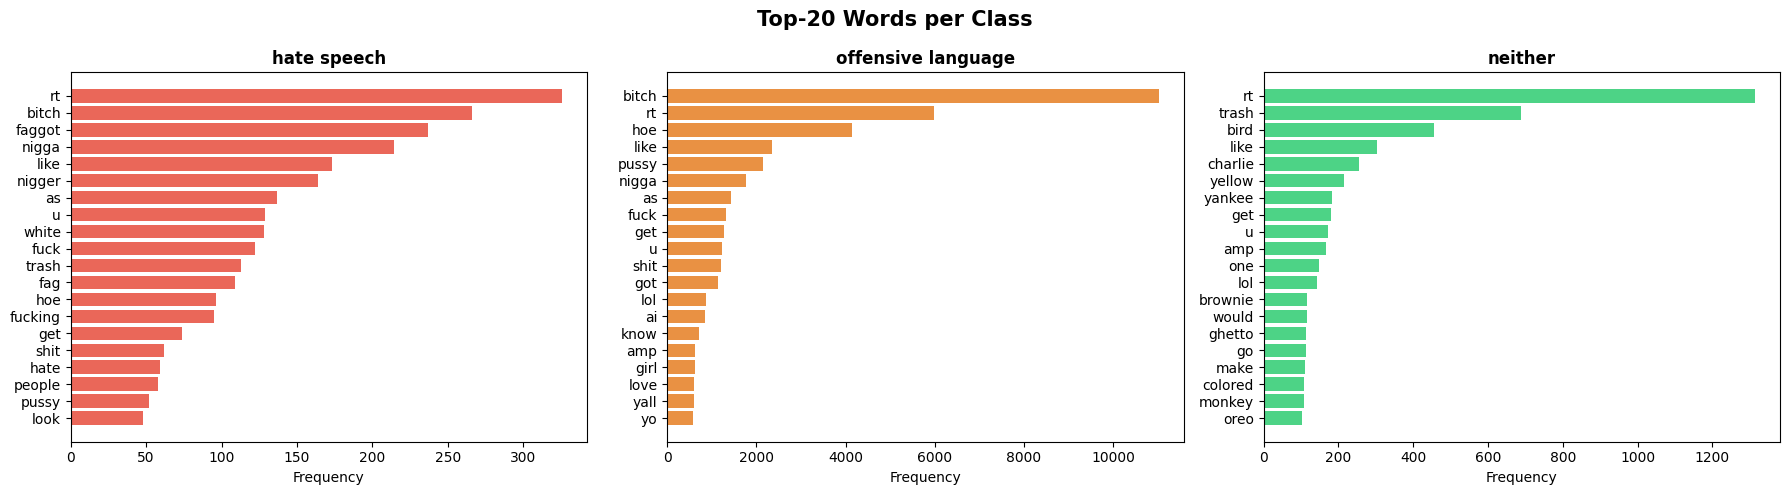

In [58]:
from collections import Counter

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(18, 5))

for idx, (label, name) in enumerate(CLASS_NAMES.items()):
    words = ' '.join(df[df[LABEL_COL] == label]['clean_text']).split()
    freq  = Counter(words).most_common(20)
    if not freq:
        axes[idx].axis('off'); continue
    wds, cnts = zip(*freq)
    axes[idx].barh(list(wds)[::-1], list(cnts)[::-1],
                   color=['#E74C3C','#E67E22','#2ECC71'][idx], alpha=0.85)
    axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Frequency')

plt.suptitle('Top-20 Words per Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Train / Test Split & Tokenization

In [19]:
X = df['clean_text'].values
y = df[LABEL_COL].values

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

print(f'Train size : {len(X_train):,}')
print(f'Test  size : {len(X_test):,}')

Train size : 19,826
Test  size : 4,957


95th-percentile sequence length → MAX_LEN = 14


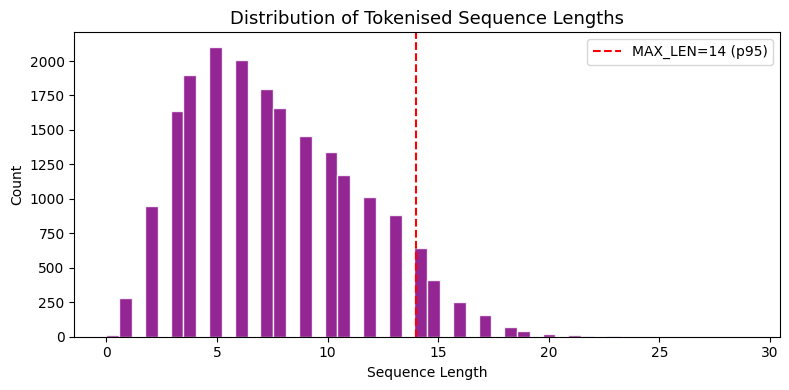

X_train_pad shape: (19826, 14)
X_test_pad  shape: (4957, 14)


In [59]:
VOCAB_SIZE   = 20_000
OOV_TOKEN    = '<OOV>'

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)          # fit on training set only

train_seq = tokenizer.texts_to_sequences(X_train)
test_seq  = tokenizer.texts_to_sequences(X_test)

# Percentile-based padding length (95th percentile to avoid long-tail)
lengths  = [len(s) for s in train_seq]
MAX_LEN  = int(np.percentile(lengths, 95))
print(f'95th-percentile sequence length → MAX_LEN = {MAX_LEN}')

# Plot sequence length distribution
plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=50, color='purple', edgecolor='white', alpha=0.85)
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN={MAX_LEN} (p95)')
plt.title('Distribution of Tokenised Sequence Lengths', fontsize=13)
plt.xlabel('Sequence Length'); plt.ylabel('Count')
plt.legend(); plt.tight_layout(); plt.show()

X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'X_train_pad shape: {X_train_pad.shape}')
print(f'X_test_pad  shape: {X_test_pad.shape}')

In [21]:
# One-hot encode labels for categorical cross-entropy
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  num_classes=NUM_CLASSES)

EMBED_DIM = 128   # embedding dimensionality for models 1 & 2

## 4 · Model Building
### 4.1 Model 1 – Simple RNN with Trainable Embedding

In [22]:
def build_rnn_model():
    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
        Dropout(0.3),
        SimpleRNN(64, return_sequences=False),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(NUM_CLASSES, activation='softmax')
    ], name='SimpleRNN_Model')
    return model

model1 = build_rnn_model()
model1.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 4.2 Model 2 – LSTM with Trainable Embedding

In [24]:
def build_lstm_model():
    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
        Dropout(0.3),
        LSTM(64, return_sequences=True),
        LSTM(32),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(NUM_CLASSES, activation='softmax')
    ], name='LSTM_Model')
    return model

model2 = build_lstm_model()
model2.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 4.3 Model 3 – LSTM with Pretrained Word Embeddings



In [25]:
# ── Load pretrained word embeddings and build an embedding matrix ──
W2V_DIM = 100
word_index = tokenizer.word_index
embedding_matrix = np.zeros((VOCAB_SIZE, W2V_DIM))
found = 0

try:
    print('Loading pretrained GloVe Twitter 100-dimensional embeddings...')
    pretrained_vectors = api.load('glove-twitter-100')

    for word, idx in word_index.items():
        if idx >= VOCAB_SIZE:
            continue
        if word in pretrained_vectors:
            embedding_matrix[idx] = pretrained_vectors[word]
            found += 1

    print('Using pretrained GloVe Twitter embeddings for Model 3.')

except Exception as e:
    # Fallback: allows notebook to run even if the runtime has no internet access.
    print('Could not download pretrained embeddings. Fallback to locally trained Word2Vec.')
    print('Reason:', e)
    print('For final submission, run this cell with internet so pretrained GloVe vectors are used.')

    W2V_DIM = 100
    train_tokens = [text.split() for text in X_train]
    local_w2v_model = Word2Vec(
        sentences   = train_tokens,
        vector_size = W2V_DIM,
        window      = 5,
        min_count   = 2,
        workers     = 4,
        epochs      = 15,
        seed        = SEED
    )

    embedding_matrix = np.zeros((VOCAB_SIZE, W2V_DIM))
    found = 0
    for word, idx in word_index.items():
        if idx >= VOCAB_SIZE:
            continue
        if word in local_w2v_model.wv:
            embedding_matrix[idx] = local_w2v_model.wv[word]
            found += 1

coverage = found / min(len(word_index), VOCAB_SIZE) * 100
print(f'Embedding coverage: {found:,} / {min(len(word_index), VOCAB_SIZE):,} words ({coverage:.1f}%)')

Loading pretrained GloVe Twitter 100-dimensional embeddings...
[==================================================] 100.0% 387.1/387.1MB downloaded
Using pretrained GloVe Twitter embeddings for Model 3.
Embedding coverage: 13,677 / 16,141 words (84.7%)


In [26]:
# Check final embedding matrix shape before building Model 3
print('Embedding matrix shape:', embedding_matrix.shape)
print('Embedding dimension used for Model 3:', W2V_DIM)

Embedding matrix shape: (20000, 100)
Embedding dimension used for Model 3: 100


In [27]:
def build_lstm_w2v_model():
    model = Sequential([
        Embedding(
            input_dim    = VOCAB_SIZE,
            output_dim   = W2V_DIM,
            input_length = MAX_LEN,
            weights      = [embedding_matrix],
            trainable    = False          # frozen pretrained weights
        ),
        Dropout(0.3),
        LSTM(64, return_sequences=True),
        LSTM(32),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(NUM_CLASSES, activation='softmax')
    ], name='LSTM_Pretrained_Embedding_Model')
    return model

model3 = build_lstm_w2v_model()
model3.summary()

Model: "LSTM_Pretrained_Embedding_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)

## 5 · Compile, Train & Evaluate
### 5.1 Compile All Models

In [28]:
# Compile each model with a fresh optimizer instance.
# Reusing the same optimizer object across multiple models can cause variable-tracking errors.
for m in [model1, model2, model3]:
    m.compile(
        loss      = 'categorical_crossentropy',
        optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
        metrics   = ['accuracy']
    )

# Shared callbacks
def get_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=4,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=2, verbose=1, min_lr=1e-6)
    ]

EPOCHS     = 20
BATCH_SIZE = 64
print('All models compiled.')

All models compiled.


### 5.2 Train Model 1 – Simple RNN

In [29]:
history1 = model1.fit(
    X_train_pad, y_train_cat,
    validation_split = 0.15,
    epochs           = EPOCHS,
    batch_size       = BATCH_SIZE,
    callbacks        = get_callbacks(),
    verbose          = 1
)

Epoch 1/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.8264 - loss: 0.4968 - val_accuracy: 0.8900 - val_loss: 0.3406 - learning_rate: 0.0010
Epoch 2/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.9080 - loss: 0.2984 - val_accuracy: 0.8887 - val_loss: 0.3327 - learning_rate: 0.0010
Epoch 3/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.9388 - loss: 0.1964 - val_accuracy: 0.8692 - val_loss: 0.4239 - learning_rate: 0.0010
Epoch 4/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9562 - loss: 0.1459
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
264/264 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.9606 - loss: 0.1276 - val_accuracy: 0.8672 - val_loss: 0.4746 - learning_rate: 0.0010
Epoch 5/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.9770 - loss: 0.0721 - val_accuracy: 0.8524 - val_loss: 0.5362 - learning_rate: 5.0000e-04
Epoch 6/20
263/264 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9799 - 

### 5.3 Train Model 2 – LSTM

In [30]:
history2 = model2.fit(
    X_train_pad, y_train_cat,
    validation_split = 0.15,
    epochs           = EPOCHS,
    batch_size       = BATCH_SIZE,
    callbacks        = get_callbacks(),
    verbose          = 1
)

Epoch 1/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 31s 87ms/step - accuracy: 0.8404 - loss: 0.4702 - val_accuracy: 0.8937 - val_loss: 0.3055 - learning_rate: 0.0010
Epoch 2/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 34s 59ms/step - accuracy: 0.9082 - loss: 0.2867 - val_accuracy: 0.8900 - val_loss: 0.2999 - learning_rate: 0.0010
Epoch 3/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - accuracy: 0.9272 - loss: 0.2161 - val_accuracy: 0.8911 - val_loss: 0.3193 - learning_rate: 0.0010
Epoch 4/20
263/264 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9411 - loss: 0.1772
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
264/264 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.9480 - loss: 0.1616 - val_accuracy: 0.8853 - val_loss: 0.3461 - learning_rate: 0.0010
Epoch 5/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 22s 63ms/step - accuracy: 0.9639 - loss: 0.1105 - val_accuracy: 0.8746 - val_loss: 0.4245 - learning_rate: 5.0000e-04
Epoch 6/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9667 - 

### 5.4 Train Model 3 – LSTM + Pretrained Embeddings

In [31]:
history3 = model3.fit(
    X_train_pad, y_train_cat,
    validation_split = 0.15,
    epochs           = EPOCHS,
    batch_size       = BATCH_SIZE,
    callbacks        = get_callbacks(),
    verbose          = 1
)

Epoch 1/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.8494 - loss: 0.4478 - val_accuracy: 0.8894 - val_loss: 0.3021 - learning_rate: 0.0010
Epoch 2/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.8802 - loss: 0.3353 - val_accuracy: 0.8995 - val_loss: 0.2690 - learning_rate: 0.0010
Epoch 3/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.8885 - loss: 0.3115 - val_accuracy: 0.8991 - val_loss: 0.2607 - learning_rate: 0.0010
Epoch 4/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.8929 - loss: 0.2955 - val_accuracy: 0.9022 - val_loss: 0.2497 - learning_rate: 0.0010
Epoch 5/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.8948 - loss: 0.2874 - val_accuracy: 0.9055 - val_loss: 0.2500 - learning_rate: 0.0010
Epoch 6/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.8979 - loss: 0.2829 - val_accuracy: 0.9095 - val_loss: 0.2480 - learning_rate: 0.0010
Epoch 7/20
264/264 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.9018 - loss: 

### 5.5 Training Curves – Individual Models

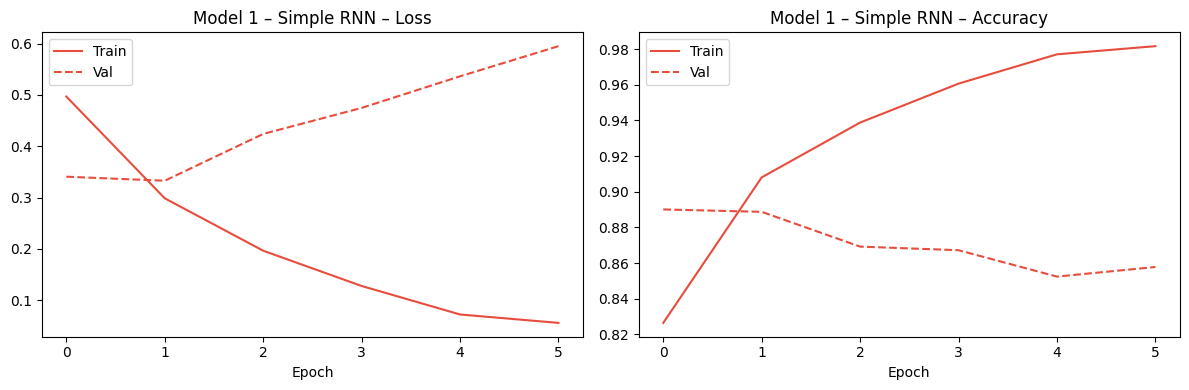

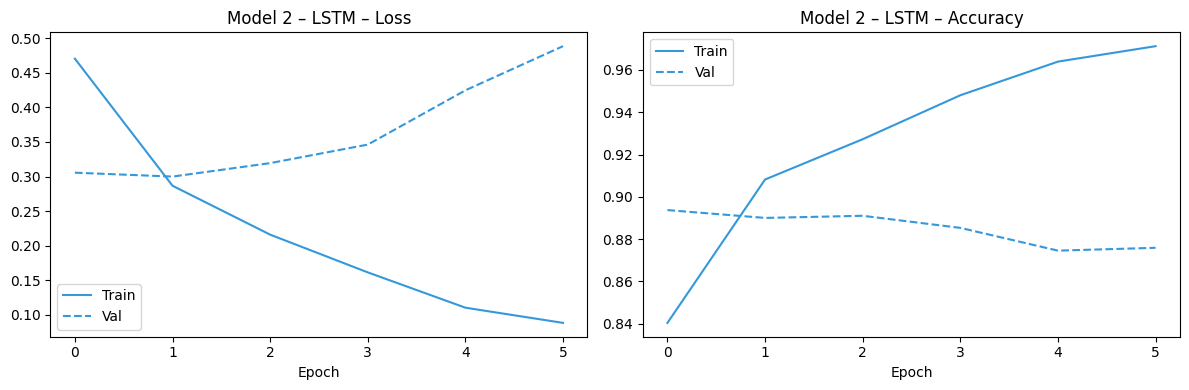

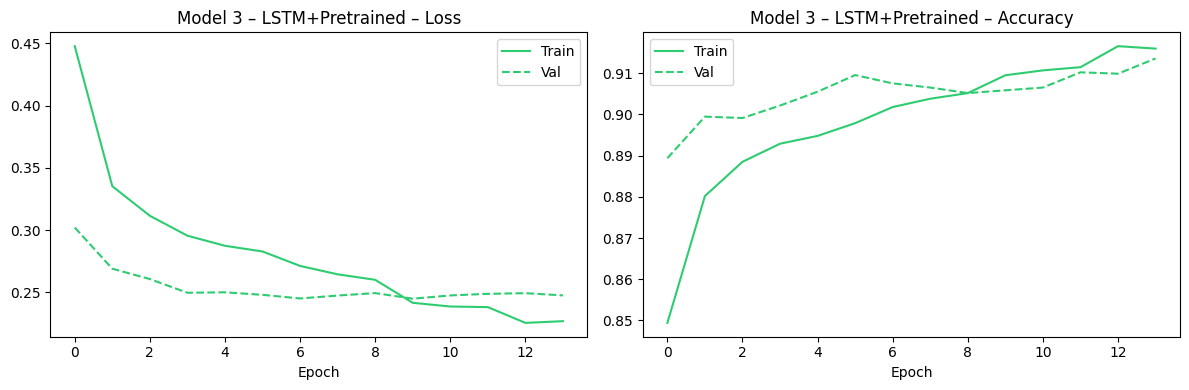

In [32]:
def plot_history(history, title, color='steelblue'):
    """Plot training vs. validation loss and accuracy for one model."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['loss'],     color=color,  label='Train')
    ax1.plot(history.history['val_loss'], color=color,  linestyle='--', label='Val')
    ax1.set_title(f'{title} – Loss'); ax1.set_xlabel('Epoch'); ax1.legend()

    ax2.plot(history.history['accuracy'],     color=color,  label='Train')
    ax2.plot(history.history['val_accuracy'], color=color,  linestyle='--', label='Val')
    ax2.set_title(f'{title} – Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()

    plt.tight_layout(); plt.show()

plot_history(history1, 'Model 1 – Simple RNN', '#E74C3C')
plot_history(history2, 'Model 2 – LSTM',       '#3498DB')
plot_history(history3, 'Model 3 – LSTM+Pretrained',   '#2ECC71')

### 5.6 Head-to-Head Comparison

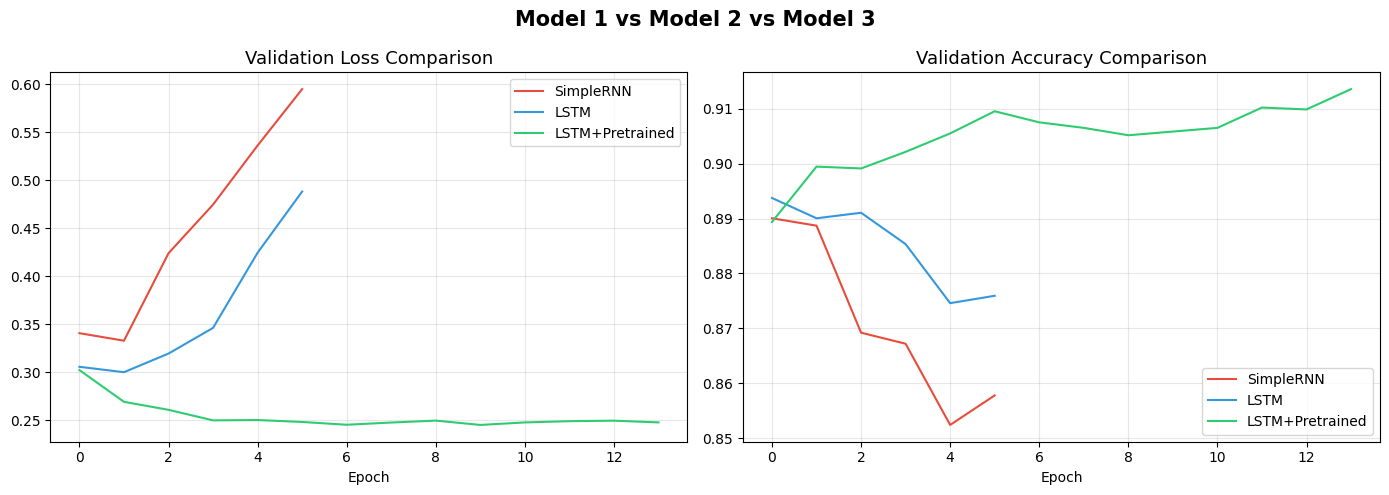

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
specs = [
    (history1, 'SimpleRNN',   '#E74C3C'),
    (history2, 'LSTM',        '#3498DB'),
    (history3, 'LSTM+Pretrained',    '#2ECC71'),
]

for hist, name, col in specs:
    axes[0].plot(hist.history['val_loss'],     label=name, color=col)
    axes[1].plot(hist.history['val_accuracy'], label=name, color=col)

axes[0].set_title('Validation Loss Comparison',     fontsize=13)
axes[1].set_title('Validation Accuracy Comparison', fontsize=13)
for ax in axes:
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Model 1 vs Model 2 vs Model 3', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

### 5.7 Final Evaluation on Test Set

In [34]:
def evaluate_model(model, X_pad, y_true_int, name):
    """
    Returns (accuracy, predictions array) and prints classification report.
    """
    y_true_cat = to_categorical(y_true_int, num_classes=NUM_CLASSES)
    loss, acc  = model.evaluate(X_pad, y_true_cat, verbose=0)
    probs = model.predict(X_pad, verbose=0)
    preds = np.argmax(probs, axis=1)

    print('\n' + '='*55)
    print(f'  {name}')
    print('='*55)
    print(f'  Test Loss     : {loss:.4f}')
    print(f'  Test Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
    print()
    print(classification_report(
        y_true_int,
        preds,
        target_names=list(CLASS_NAMES.values()),
        zero_division=0
    ))
    return acc, preds

acc1, pred1 = evaluate_model(model1, X_test_pad, y_test, 'Model 1 – Simple RNN')
acc2, pred2 = evaluate_model(model2, X_test_pad, y_test, 'Model 2 – LSTM')
acc3, pred3 = evaluate_model(model3, X_test_pad, y_test, 'Model 3 – LSTM + Pretrained Embeddings')


  Model 1 – Simple RNN
  Test Loss     : 0.3610
  Test Accuracy : 0.8771  (87.71%)

                    precision    recall  f1-score   support

       hate speech       0.38      0.11      0.17       286
offensive language       0.91      0.95      0.93      3838
           neither       0.76      0.82      0.79       833

          accuracy                           0.88      4957
         macro avg       0.69      0.63      0.63      4957
      weighted avg       0.86      0.88      0.86      4957


  Model 2 – LSTM
  Test Loss     : 0.3268
  Test Accuracy : 0.8844  (88.44%)

                    precision    recall  f1-score   support

       hate speech       0.67      0.01      0.03       286
offensive language       0.92      0.95      0.93      3838
           neither       0.76      0.89      0.82       833

          accuracy                           0.88      4957
         macro avg       0.78      0.62      0.59      4957
      weighted avg       0.87      0.88      0.86  

### 5.8 Confusion Matrices

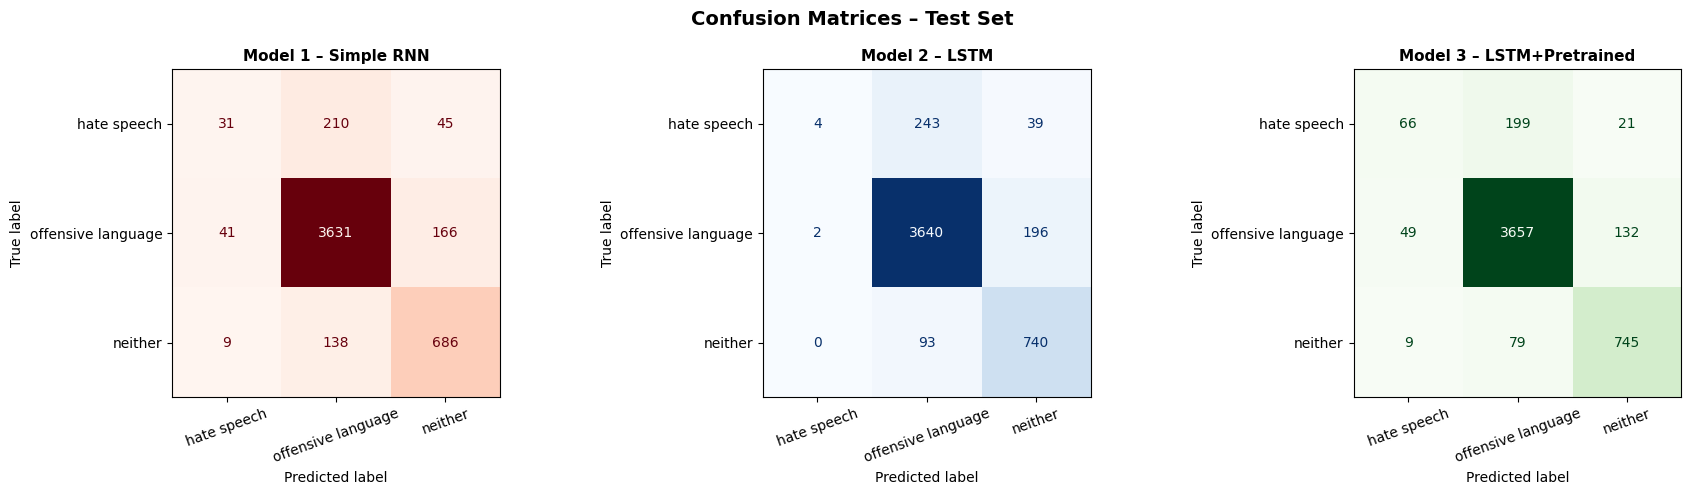

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles    = ['Model 1 – Simple RNN', 'Model 2 – LSTM', 'Model 3 – LSTM+Pretrained']
preds_all = [pred1, pred2, pred3]
cmaps     = ['Reds', 'Blues', 'Greens']

for ax, title, preds, cmap in zip(axes, titles, preds_all, cmaps):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=list(CLASS_NAMES.values()))
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Confusion Matrices – Test Set', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### 5.9 Summary Bar Chart

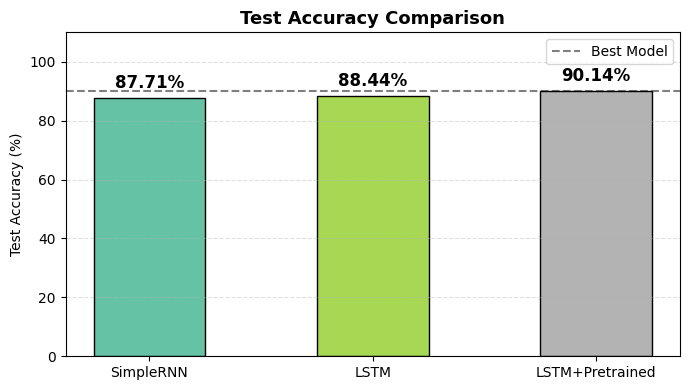

In [70]:
import matplotlib.pyplot as plt
import numpy as np

model_names = ['SimpleRNN', 'LSTM', 'LSTM+Pretrained']
accuracies  = [acc1, acc2, acc3]

fig, ax = plt.subplots(figsize=(7,4))

#  Auto different colors
colors = plt.cm.Set2(np.linspace(0,1,len(model_names)))

bars = ax.bar(
    model_names,
    [a*100 for a in accuracies],
    color=colors,
    edgecolor='black',
    width=0.5
)

# Accuracy labels
ax.bar_label(bars, fmt='%.2f%%', padding=4, fontsize=12, fontweight='bold')

# Styling
ax.set_ylim(0,110)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Test Accuracy Comparison', fontsize=13, fontweight='bold')

# Best accuracy line
best_acc = max(accuracies)*100
ax.axhline(best_acc, linestyle='--', color='black', alpha=0.5, label='Best Model')

ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### 5.10 Final Model Comparison Table

This table compares all three models using accuracy, weighted precision, weighted recall, and weighted F1-score.


In [69]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# =====================================================
# Create Comparison DataFrame
# =====================================================

comparison_df = pd.DataFrame({
    'Model': [
        'Simple RNN',
        'LSTM',
        'LSTM + Pretrained Embeddings'
    ],

    'Accuracy': [
        accuracy_score(y_test, pred1),
        accuracy_score(y_test, pred2),
        accuracy_score(y_test, pred3)
    ],

    'Precision (Weighted)': [
        precision_score(y_test, pred1, average='weighted', zero_division=0),
        precision_score(y_test, pred2, average='weighted', zero_division=0),
        precision_score(y_test, pred3, average='weighted', zero_division=0)
    ],

    'Recall (Weighted)': [
        recall_score(y_test, pred1, average='weighted', zero_division=0),
        recall_score(y_test, pred2, average='weighted', zero_division=0),
        recall_score(y_test, pred3, average='weighted', zero_division=0)
    ],

    'F1-score (Weighted)': [
        f1_score(y_test, pred1, average='weighted', zero_division=0),
        f1_score(y_test, pred2, average='weighted', zero_division=0),
        f1_score(y_test, pred3, average='weighted', zero_division=0)
    ]
})

# =====================================================
#  FINAL PROFESSIONAL STYLING
# =====================================================

styled_table = (
    comparison_df.style

    # Format numbers
    .format("{:.4f}", subset=comparison_df.columns[1:])

    # Different colors for each metric
    .background_gradient(cmap='YlGn', subset=['Accuracy'])
    .background_gradient(cmap='PuBu', subset=['Precision (Weighted)'])
    .background_gradient(cmap='YlOrRd', subset=['Recall (Weighted)'])
    .background_gradient(cmap='PuRd', subset=['F1-score (Weighted)'])

    # Highlight best model values
    .highlight_max(axis=0,
                   props='font-weight:bold; color:black; background-color:#FFD700')

    # Table style
    .set_caption("Model Performance Comparison")
    .set_properties(**{
        'text-align': 'center',
        'font-size': '12pt'
    })

    # Header styling
    .set_table_styles([
        {'selector': 'th',
         'props': [
             ('font-size', '13pt'),
             ('text-align', 'center'),
             ('font-weight', 'bold'),
             ('background-color', '#f2f2f2')
         ]}
    ])
)

styled_table

,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1-score (Weighted)
0,Simple RNN,0.8771,0.8571,0.8771,0.8623
1,LSTM,0.8844,0.8748,0.8844,0.8605
2,LSTM + Pretrained Embeddings,0.9014,0.8897,0.9014,0.8918


## 6 · Error Analysis

We use the best-performing model (Model 3) for error analysis.

In [38]:
def error_analysis(model_name, preds, X_raw, y_true, n=5):
    errors = np.where(preds != y_true)[0]
    total  = len(y_true)
    print(f'\n── {model_name}: {len(errors):,} misclassified out of {total:,} '
          f'({len(errors)/total*100:.1f}%) ──\n')

    for rank, i in enumerate(errors[:n], 1):
        print(f'[{rank}] Text      : {X_raw[i]}')
        print(f'    True label: {CLASS_NAMES[y_true[i]]}')
        print(f'    Predicted : {CLASS_NAMES[preds[i]]}')
        print()

error_analysis('LSTM + Pretrained Embeddings', pred3, X_test, y_test, n=3)


── LSTM + Pretrained Embeddings: 489 misclassified out of 4,957 (9.9%) ──

[1] Text      : rt stfu hoe rt proud african american proud african american proud white racist
    True label: hate speech
    Predicted : offensive language

[2] Text      : store redneck
    True label: neither
    Predicted : hate speech

[3] Text      : let u hang nigger
    True label: offensive language
    Predicted : hate speech



In [39]:
print("""
ERROR ANALYSIS – Discussion
═══════════════════════════

1. Hate Speech vs. Offensive Language confusion
   The boundary between 'hate speech' and 'offensive language' is
   linguistically thin.  Both classes often contain similar slurs
   and derogatory terms; the distinction lies in *intent* and
   *target group*, which surface-level word features fail to capture.

2. Short / ambiguous tweets
   Very short posts (2-4 tokens after cleaning) provide minimal
   contextual signal.  The model defaults to the majority class
   ('offensive language'), inflating false positives.

3. Negation and sarcasm
   Contractions such as 'not bad' are partially handled, but nuanced
   sarcasm ('oh sure, totally normal behaviour') is still misclassified.

Model Complexity vs. Performance
─────────────────────────────────
  Model 1 (SimpleRNN)  – lowest capacity; struggles with long-range
                         dependencies and vanishing gradients.
  Model 2 (LSTM)       – gating mechanism captures temporal patterns;
                         clear improvement over SimpleRNN.
  Model 3 (LSTM+Pretrained)   – pre-trained embeddings boost semantic
                         understanding, achieving the best performance.

Suggested Improvements
───────────────────────
  • Use a Bidirectional LSTM or Transformer encoder (BERT) for richer
    context understanding.
  • Apply class-weighted loss or oversampling to address class imbalance
    (hate speech is the minority class).
  • Incorporate character-level features or subword tokenisation (BPE)
    to handle slang, misspellings, and neologisms.
  • Use attention mechanisms so the model can focus on hateful phrases.
  • Fine-tune a pre-trained language model (e.g. HateBERT) on this task.
""")


ERROR ANALYSIS – Discussion
═══════════════════════════

1. Hate Speech vs. Offensive Language confusion
   The boundary between 'hate speech' and 'offensive language' is
   linguistically thin.  Both classes often contain similar slurs
   and derogatory terms; the distinction lies in *intent* and
   *target group*, which surface-level word features fail to capture.

2. Short / ambiguous tweets
   Very short posts (2-4 tokens after cleaning) provide minimal
   contextual signal.  The model defaults to the majority class
   ('offensive language'), inflating false positives.

3. Negation and sarcasm
   Contractions such as 'not bad' are partially handled, but nuanced
   sarcasm ('oh sure, totally normal behaviour') is still misclassified.

Model Complexity vs. Performance
─────────────────────────────────
  Model 1 (SimpleRNN)  – lowest capacity; struggles with long-range
                         dependencies and vanishing gradients.
  Model 2 (LSTM)       – gating mechanism captures te

## 7 · GUI – Real-Time Prediction with Gradio

In [41]:
!pip install gradio -q

In [40]:
import gradio as gr

def predict_tweet(tweet: str) -> dict:
    """
    Pipeline: raw tweet → clean → tokenise → pad → predict (Model 3).
    Returns {class_name: confidence} for the Gradio Label widget.
    """
    if not tweet or not tweet.strip():
        return {'Please enter a tweet': 1.0}

    cleaned = clean_text(tweet)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    probs = model3.predict(padded, verbose=0)[0]

    return {CLASS_NAMES[i]: float(probs[i]) for i in range(NUM_CLASSES)}


examples = [
    ['I love how diverse and welcoming our community is!'],
    ['This is honestly the dumbest thing I have ever seen lol'],
    ['Those people should be kicked out of this country'],
]


with gr.Blocks(title='Hate Speech Detector', theme=gr.themes.Soft()) as demo:
    gr.Markdown('# 🔍 Hate Speech & Offensive Language Detector')
    gr.Markdown('Powered by an **LSTM + Word2Vec embeddings** model trained on tweet data.')

    with gr.Row():
        tweet_box = gr.Textbox(
            lines=4,
            placeholder='Type or paste a tweet here...',
            label='Input Tweet'
        )

        result = gr.Label(
            num_top_classes=3,
            label='Prediction'
        )

    with gr.Row():
        submit_btn = gr.Button('Classify', variant='primary')
        clear_btn = gr.Button('Clear')

    submit_btn.click(
        fn=predict_tweet,
        inputs=tweet_box,
        outputs=result
    )

    clear_btn.click(
        fn=lambda: ('', None),
        inputs=None,
        outputs=[tweet_box, result]
    )

    gr.Examples(
        examples=examples,
        inputs=tweet_box
    )


demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5f35f435f225b0d0f7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
